In [19]:
# Imports
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, ConfusionMatrixDisplay, f1_score

import matplotlib.pyplot as plt
import seaborn as sns

# Load your parquet training dataset
df = pd.read_parquet("../data/train_NYC_inspection.parquet")

df.head(10)

,CUISINE DESCRIPTION,BORO,ZIPCODE,Latitude,Longitude,INSPECTION DATE,BUILDING,STREET,GRADE
0,Chinese,Queens,11354.0,40.759778,-73.829235,2024-08-05,136-20,ROOSEVELT AVENUE,A
1,Coffee/Tea,Queens,11362.0,40.769834,-73.736180,2025-10-31,25201,NORTHERN BLVD,A
2,Japanese,Manhattan,10036.0,40.759161,-73.990369,2025-05-02,354,WEST 44 STREET,B
3,Pizza,Queens,11372.0,40.756245,-73.878681,2025-04-15,8906,NORTHERN BLVD,C
4,Chicken,Queens,11432.0,40.708211,-73.803110,2024-02-29,87-44,PARSONS BOULEVARD,None
5,"Juice, Smoothies, Fruit Salads",Brooklyn,11217.0,40.674889,-73.975183,2025-04-30,82,7 AVENUE,None
6,Chinese,Manhattan,10013.0,40.715443,-73.997951,2025-01-22,60,BAYARD STREET,None
7,Latin American,Bronx,NaN,0.000000,0.000000,2025-01-09,55925594,BROADWAY,None
8,Sandwiches,Manhattan,10003.0,40.736898,-73.990503,2025-02-12,39,UNION SQUARE WEST,A
9,Chicken,Queens,11432.0,40.703485,-73.799838,2025-04-17,15929,JAMAICA AVE,A


In [20]:
# Data Cleaning

# Data cleaning: drop rows with missing target (GRADE)
df = df.dropna(subset=["GRADE"])

# Impute remaining numeric missing values with median
num_cols = df.select_dtypes(include=[np.number]).columns
for c in num_cols:
    df[c] = df[c].fillna(df[c].median())

In [21]:
# Define Features and Target

target_col = "GRADE"
y = df[target_col]

# Drop columns not used as features, including SCORE and target
X = df.drop(
    columns=[
        target_col,
        "SCORE",          
        "INSPECTION DATE",
        "BUILDING",
        "STREET"
    ],
    errors="ignore"     
)

# Encode categorical features: CUISINE DESCRIPTION and BORO
from sklearn.preprocessing import LabelEncoder

if "CUISINE DESCRIPTION" in X.columns:
    cuisine_encoder = LabelEncoder()
    X["CUISINE_ENCODED"] = cuisine_encoder.fit_transform(X["CUISINE DESCRIPTION"])
    X = X.drop(columns=["CUISINE DESCRIPTION"])

if "BORO" in X.columns:
    boro_encoder = LabelEncoder()
    X["BORO_ENCODED"] = boro_encoder.fit_transform(X["BORO"])
    X = X.drop(columns=["BORO"])

# Keep only numeric columns as final features
X = X.select_dtypes(include=["number"]).copy()

print("Number of numeric features:", X.shape[1])
print("Feature columns:", list(X.columns))

Number of numeric features: 5
Feature columns: ['ZIPCODE', 'Latitude', 'Longitude', 'CUISINE_ENCODED', 'BORO_ENCODED']


In [22]:
# Use the full parquet file as training data
X_train = X
y_train = y

print("Training shape:", X_train.shape)
print("Class distribution in training data:\n", y_train.value_counts())

Training shape: (68423, 5)
Class distribution in training data:
 GRADE
A    43081
B     8109
C     6493
N     5544
Z     4898
P      298
Name: count, dtype: int64


In [23]:
# Pipeline with class_weight balanced
log_pipe_balanced = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        multi_class="multinomial",
        solver="lbfgs",
        max_iter=300,
        class_weight="balanced"
    ))
])

# Hyperparameter grid
param_grid_balanced = {
    "logreg__C": [0.01, 0.1, 1.0]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Grid search
log_gs_balanced = GridSearchCV(
    estimator=log_pipe_balanced,
    param_grid=param_grid_balanced,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

log_gs_balanced.fit(X_train, y_train)

best_balanced = log_gs_balanced.best_estimator_

# Predictions on the *training* data
y_train_pred = best_balanced.predict(X_train)

# Training F1 scores
train_macro_f1 = f1_score(y_train, y_train_pred, average="macro")
train_weighted_f1 = f1_score(y_train, y_train_pred, average="weighted")

print(f"Training Macro F1 score: {train_macro_f1:.4f}")
print(f"Training Weighted F1 score: {train_weighted_f1:.4f}")


Fitting 5 folds for each of 3 candidates, totalling 15 fits


/opt/anaconda3/envs/virtual_env/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/virtual_env/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/virtual_env/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/virtual_env/lib/python3.13/site-packages/sklearn/linear_model/

Training Macro F1 score: 0.1371
Training Weighted F1 score: 0.2898


In [24]:
# Report best hyperparameters and cross-validated accuracy
best_C = log_gs_balanced.best_params_["logreg__C"]
best_cv_acc = log_gs_balanced.best_score_

best_cv_f1 = log_gs_balanced.best_score_
print(f"Best C value: {best_C}")
print(f"Best cross-validated Macro F1: {best_cv_f1:.4f}")

Best C value: 0.01
Best cross-validated Macro F1: 0.1358


Training accuracy: 0.2311


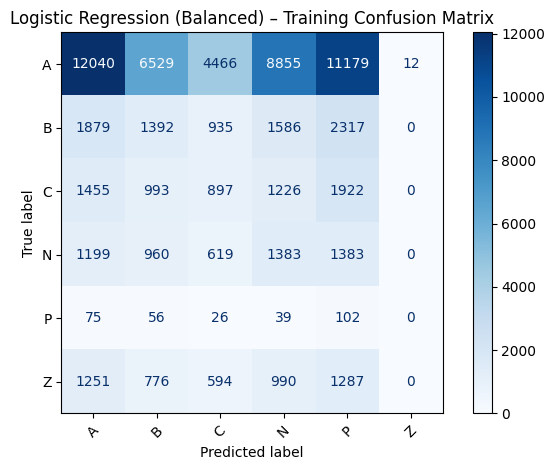

In [25]:
# Evaluate on training data
best_logreg = log_gs_balanced.best_estimator_

y_train_pred = best_logreg.predict(X_train)

train_acc = accuracy_score(y_train, y_train_pred)
print(f"Training accuracy: {train_acc:.4f}")

cm = confusion_matrix(y_train, y_train_pred, labels=sorted(y.unique()))

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=sorted(y.unique()))
disp.plot(cmap="Blues", xticks_rotation=45)

plt.title("Logistic Regression (Balanced) – Training Confusion Matrix")
plt.tight_layout()
plt.savefig("../output/figures/logreg_balanced_confusion_matrix_train.png",
            dpi=300, bbox_inches="tight")
plt.show()

In [26]:
# Inspect learned coefficients
coef_matrix = best_logreg.named_steps["logreg"].coef_

print("Number of classes:", coef_matrix.shape[0])
print("Number of features:", coef_matrix.shape[1])

coefs = pd.DataFrame(
    coef_matrix,
    columns=X.columns,
    index=best_logreg.named_steps["logreg"].classes_
)

coefs

Number of classes: 6
Number of features: 5


,ZIPCODE,Latitude,Longitude,CUISINE_ENCODED,BORO_ENCODED
A,-0.087489,-0.112638,-0.026913,-0.033372,-0.044590
B,0.025453,0.015906,0.036601,-0.000203,-0.059527
C,0.059874,0.090774,0.065951,0.009550,0.042182
N,-0.070693,-0.072829,-0.141100,0.078436,0.048201
P,0.092959,0.051636,-0.021714,-0.095940,-0.009117
Z,-0.020104,0.027151,0.087176,0.041530,0.022850


The Logistic Regression model uses L2 regularization to stabilize the learned coefficients and reduce overfitting when predicting inspection grades. The modeling pipeline standardizes all numeric features within the cross-validation loop to prevent data leakage and ensure that every hyperparameter setting is evaluated under identical preprocessing conditions. GridSearchCV tests multiple values of the regularization parameter C while using class weights to address imbalance, selecting the configuration that achieves the highest cross-validated accuracy. After tuning, the final model is evaluated on the test set using accuracy, a confusion matrix, and detailed classification metrics to understand which grades are predicted correctly and where errors occur. This workflow provides a structured and reproducible approach to building and analyzing a penalized classification model.